# m/z 142 残余峰诊断

## tl;dr

- 从 m/z 142 中扣除 `0.32 × m/z 140` 的平移峰形后，仍残留约 **75%** 的峰面积。
- 质量峰存在可预见的系统偏移，因此残余峰中心不用于接受或排除具体分子式。
- 实测残余峰 FWHM 约 **0.108 Da**，而
  $\mathrm{C_6H_3{}^{35}ClO_2}$ 与
  $\mathrm{C_7H_5{}^{37}ClO}$ 只相差 0.0178 Da。因此本数据能够确认
  “存在额外142信号”；$\mathrm{C_6H_3ClO_2}$ 是可行候选，但不能仅凭峰位确认。

## Context & Methods

### Key Assumptions

1. m/z 140 可作为纯 $\mathrm{C_7H_5{}^{35}ClO}$ 峰形模板。
2. 氯同位素面积比采用
   $^{37}\mathrm{Cl}/^{35}\mathrm{Cl}=0.32$。
3. 140峰形按精确质量对应的 TOF 位移平移到142；局部质量修正仅用于峰形对齐和绘图，不作为分子式排除依据。
4. 峰形检查使用同一 PIE 段内 9.5–11.0 eV 的30张谱平均；PIE残差使用同一段数据。

原始数据：
`/Users/huangchen/Downloads/Project_C6H5ClO/raw_data/pie_scan/PIE-总`

## Data

### 1. 重新运行残余峰计算

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

current_directory = Path.cwd()
if (current_directory / "analyze_142_residual.py").exists():
    output_dir = current_directory
    workspace = output_dir.parents[1]
else:
    workspace = current_directory
    output_dir = workspace / "analysis_outputs" / "c6h5clo_isotope_diagnostic"
script = output_dir / "analyze_142_residual.py"

environment = os.environ.copy()
environment["MPLCONFIGDIR"] = "/tmp/codex-mpl-cache"
environment["XDG_CACHE_HOME"] = "/tmp/codex-cache"
run = subprocess.run(
    [sys.executable, str(script)],
    cwd=workspace,
    env=environment,
    check=True,
    capture_output=True,
    text=True,
)
print("Residual analysis completed successfully.")

Residual analysis completed successfully.


### 2. 载入摘要与逐能量结果

In [2]:
summary = json.loads(
    (output_dir / "residual_142_summary.json").read_text(encoding="utf-8")
)
pie = pd.read_csv(output_dir / "residual_142_pie.csv")
sensitivity = pd.read_csv(output_dir / "residual_142_sensitivity.csv")

pd.DataFrame(
    {
        "metric": [
            "Residual fraction of m/z 142",
            "Residual centroid / m/z",
            "Residual FWHM / Da",
            "Required resolving power for exact-mass separation",
            "Observed resolving power from peak width",
        ],
        "value": [
            summary["residual"]["residual_fraction_of_142_profile"],
            summary["residual"]["corrected_residual_centroid_mz"],
            summary["residual"]["fwhm_da"],
            summary["formula_discrimination"]["required_resolving_power"],
            summary["formula_discrimination"][
                "observed_resolving_power_from_residual_fwhm"
            ],
        ],
    }
)

,metric,value
0,Residual fraction of m/z 142,0.750540
1,Residual centroid / m/z,142.011660
2,Residual FWHM / Da,0.108357
3,Required resolving power for exact-mass separa...,7983.089349
4,Observed resolving power from peak width,1310.588903


## Results

### 3. 峰形扣除与残余 PIE

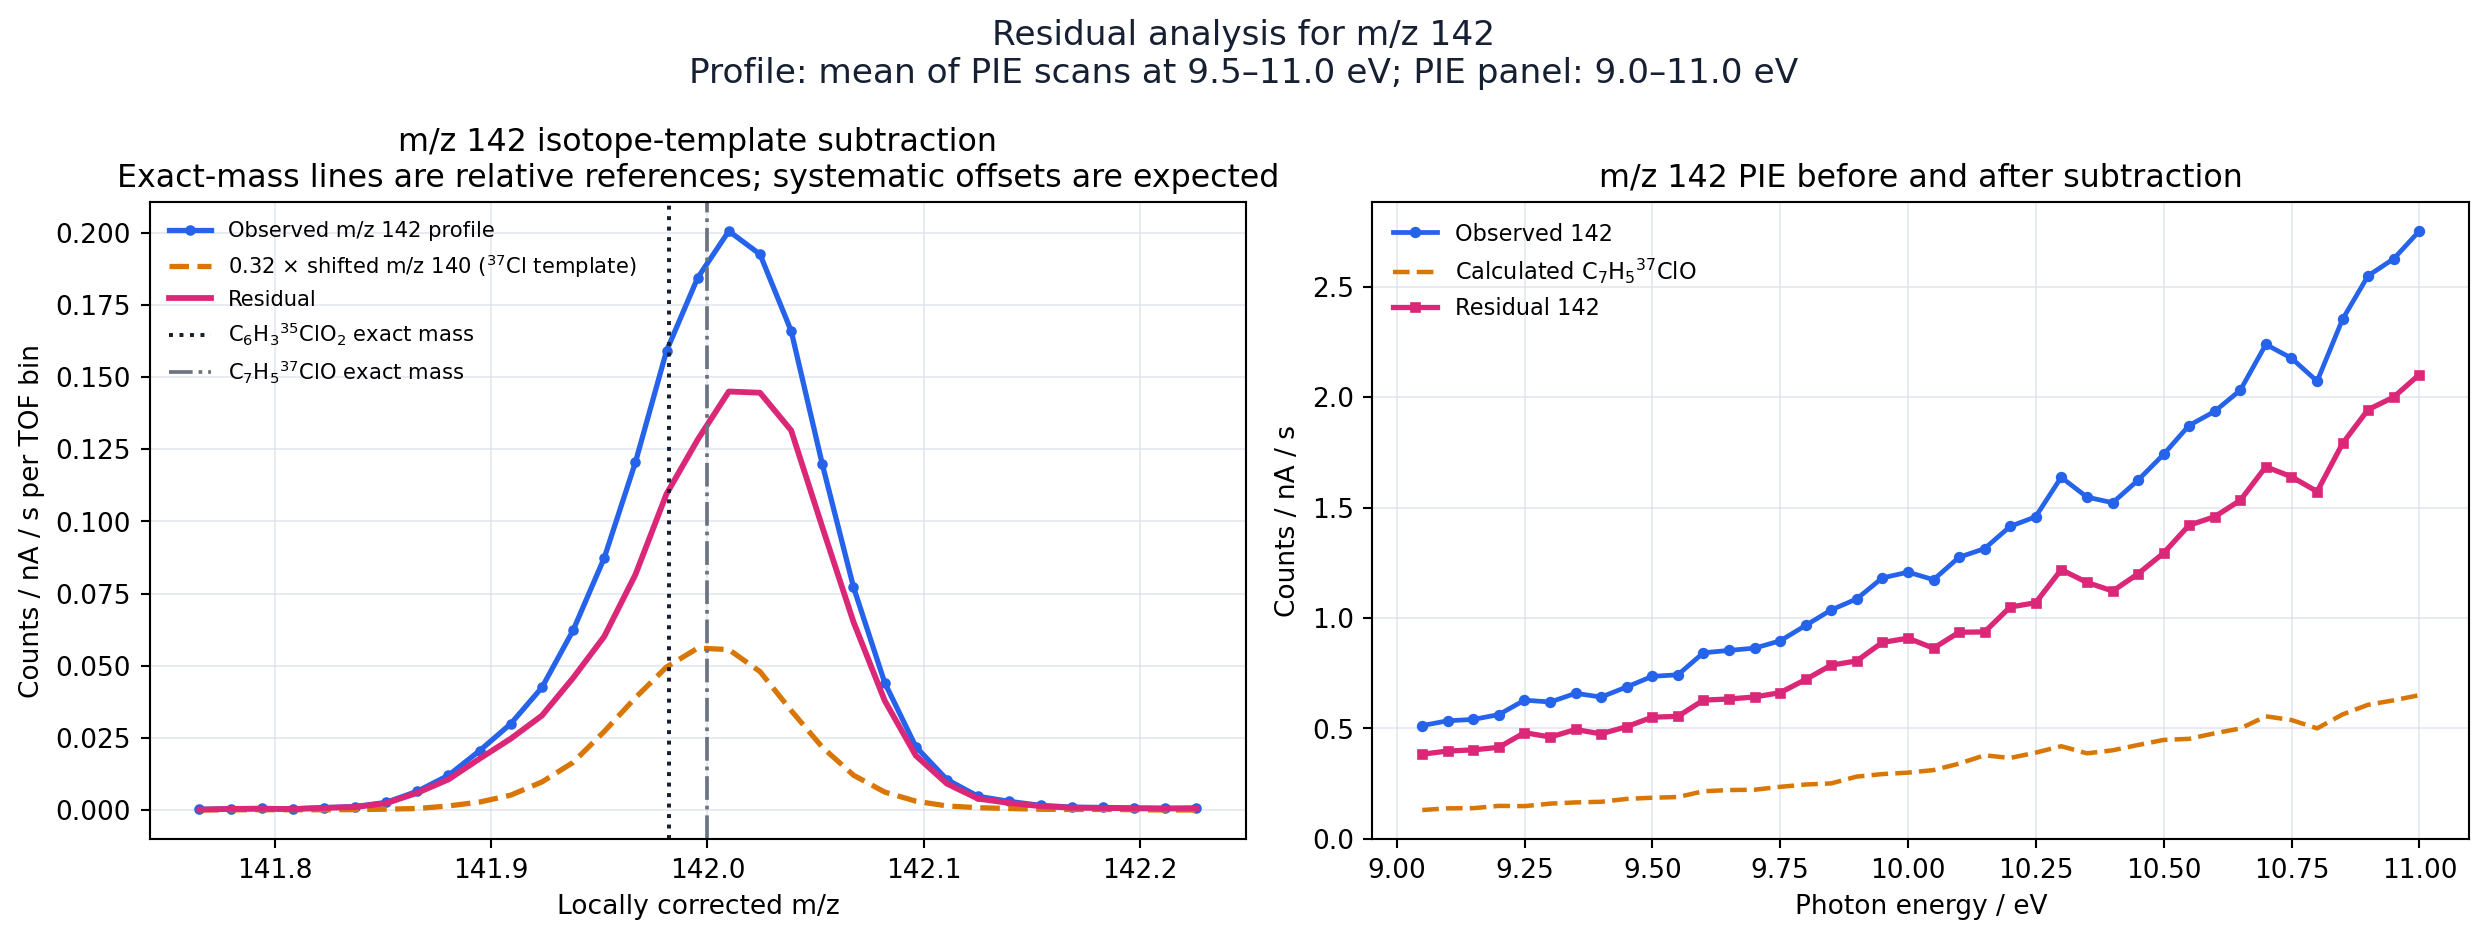

In [3]:
display(Image(filename=str(output_dir / "residual_142_diagnostic.png")))

### 4. 同位素系数灵敏度

In [4]:
sensitivity.style.format(
    {
        "isotope_ratio": "{:.2f}",
        "residual_fraction": "{:.1%}",
        "corrected_residual_centroid_mz": "{:.6f}",
        "fwhm_da": "{:.4f}",
    }
)

,isotope_ratio,residual_fraction,corrected_residual_centroid_mz,fwhm_da
0,0.30,76.6%,142.011372,0.1082
1,0.32,75.1%,142.011660,0.1084
2,0.34,73.5%,142.011963,0.1085


### 5. 144通道配对约束

In [5]:
high = pie[pie["energy_eV"] >= 9.0]
pd.DataFrame(
    {
        "check": [
            "Residual fraction of 142, median",
            "If residual is C6H3ClO2: expected 37Cl fraction of 144, median",
            "If residual is C6H3ClO2: expected 37Cl fraction of 144 at 11 eV",
        ],
        "value": [
            high["residual_fraction_of_142"].median(),
            high["expected_fraction_of_144"].median(),
            high.iloc[-1]["expected_fraction_of_144"],
        ],
    }
).style.format({"value": "{:.1%}"})

,check,value
0,"Residual fraction of 142, median",74.6%
1,"If residual is C6H3ClO2: expected 37Cl fraction of 144, median",19.9%
2,If residual is C6H3ClO2: expected 37Cl fraction of 144 at 11 eV,20.8%


### 6. 142→144→146同位素链闭合

In [6]:
chain = summary["isotope_chain_closure"]
pd.DataFrame(
    {
        "metric": [
            "146 residual fraction after isotope-chain subtraction at 11 eV",
            "Positive 146 residual points from 9–11 eV",
            "Total evaluated points from 9–11 eV",
        ],
        "value": [
            chain["i146_after_chain_fraction_at_11eV"],
            chain["i146_after_chain_positive_points_9_11"],
            chain["n_points_9_11"],
        ],
    }
)

,metric,value
0,146 residual fraction after isotope-chain subt...,0.033215
1,Positive 146 residual points from 9–11 eV,13.000000
2,Total evaluated points from 9–11 eV,40.000000


## Takeaways

1. **高置信度：** 142中存在强烈的非
   $\mathrm{C_7H_5{}^{37}ClO}$ 残余，约占总峰面积的75%。
2. **候选可行：** 质量偏移是预期的系统效应，因此残余峰的绝对中心不能否定
   $\mathrm{C_6H_3ClO_2}$。
3. **无法唯一判定：** 当前分辨本领约1310，显著低于按精确质量区分两个候选所需的约7980。
4. 若仍假设残余为 $\mathrm{C_6H_3ClO_2}$，其 ^37Cl 峰应贡献144总信号约20%；
   扣除后再由剩余144预测146，可在11 eV基本闭合同位素链。因此该分子式与强度关系相容，
   但仍需全局拟合或更高分辨率数据确认。